In [ ]:
pip show prompt_toolkit


: 

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV3Small

# Define Squeeze-and-Excitation block
def squeeze_excite_block(input_tensor, ratio=16):
    filters = input_tensor.shape[-1]
    se = layers.GlobalAveragePooling2D()(input_tensor)  # Global pooling only applied once
    se = layers.Reshape((1, 1, filters))(se)
    se = layers.Dense(filters // ratio, activation='relu', use_bias=False)(se)
    se = layers.Dense(filters, activation='sigmoid', use_bias=False)(se)
    x = layers.Multiply()([input_tensor, se])
    return x

# Define the MobileNetV3-Small model with Squeeze-and-Excitation (SE) blocks for a 5-class classification task
def create_mobilenetv3_small(input_shape=(224, 224, 3), classes=5):
    # Load the pre-trained MobileNetV3-Small model, excluding the top classification layer
    base_model = MobileNetV3Small(input_shape=input_shape, include_top=False, weights='imagenet')

    # Add SE block before global average pooling
    x = squeeze_excite_block(base_model.output)  # SE block before pooling

    # Global Average Pooling
    x = layers.GlobalAveragePooling2D()(x)

    # Dropout for regularization
    x = layers.Dropout(0.3)(x)

    # Final dense layer with softmax activation for 5 classes
    outputs = layers.Dense(classes, activation='softmax')(x)

    # Create the final model
    model = models.Model(inputs=base_model.input, outputs=outputs)

    return model

# Create the MobileNetV3-Small model
model = create_mobilenetv3_small()

# Compile the model using categorical crossentropy for multiclass classification
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Model summary
model.summary()


: 

In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping

# Define image data generators for training and validation datasets
train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)

# Load train and validation datasets from directories
train_generator = train_datagen.flow_from_directory(
    r'C:\MyFolders\Projects\major_project\classification\dataset\aptos_resized_kaggle\aug_split_data\train',  
    target_size=(224, 224),
    batch_size=8, 
    class_mode='categorical' 
)

validation_generator = val_datagen.flow_from_directory(
    r"C:\MyFolders\Projects\major_project\classification\dataset\aptos_resized_kaggle\aug_split_data\val",
    target_size=(224, 224),
    batch_size=8,
    class_mode='categorical'
)

# Train the model for 50 epochs
history = model.fit(
    train_generator,
    epochs=50, 
    validation_data=validation_generator
)

Found 8883 images belonging to 5 classes.
Found 1113 images belonging to 5 classes.
Epoch 1/50
1111/1111 [==============================] - 45s 35ms/step - loss: 0.3383 - accuracy: 0.8910 - val_loss: 2.3815 - val_accuracy: 0.2174
Epoch 2/50
1111/1111 [==============================] - 39s 35ms/step - loss: 0.2294 - accuracy: 0.9218 - val_loss: 2.1681 - val_accuracy: 0.2210
Epoch 3/50
1111/1111 [==============================] - 41s 36ms/step - loss: 0.2021 - accuracy: 0.9278 - val_loss: 2.3994 - val_accuracy: 0.2758
Epoch 4/50
1111/1111 [==============================] - 39s 36ms/step - loss: 0.1909 - accuracy: 0.9332 - val_loss: 2.3697 - val_accuracy: 0.2237
Epoch 5/50
1111/1111 [==============================] - 40s 36ms/step - loss: 0.1712 - accuracy: 0.9375 - val_loss: 3.0790 - val_accuracy: 0.1752
Epoch 6/50
1111/1111 [==============================] - 39s 35ms/step - loss: 0.1694 - accuracy: 0.9380 - val_loss: 17.4499 - val_accuracy: 0.2731
Epoch 7/50
1111/1111 [=================

In [8]:
test_datagen = ImageDataGenerator(rescale=1./255)

# Load train and validation datasets from directories
test_generator = train_datagen.flow_from_directory(
    r'C:\MyFolders\Projects\major_project\classification\dataset\aptos_resized_kaggle\aug_split_data\test',  
    target_size=(224, 224),
    batch_size=8, 
    class_mode='categorical' 
)

# Evaluate on test set
test_loss, test_acc = model.evaluate(test_generator)
print(f'Test Accuracy: {test_acc}')

Found 1110 images belonging to 5 classes.
139/139 [==============================] - 2s 16ms/step - loss: 5.2841 - accuracy: 0.1748
Test Accuracy: 0.17477478086948395


In [7]:
model.save(r"C:\MyFolders\Projects\major_project\classification\codes\aptos\mobilnetV3_aug.h5")

import pickle
with open('training_history.pkl', 'wb') as f:
    pickle.dump(history.history, f)

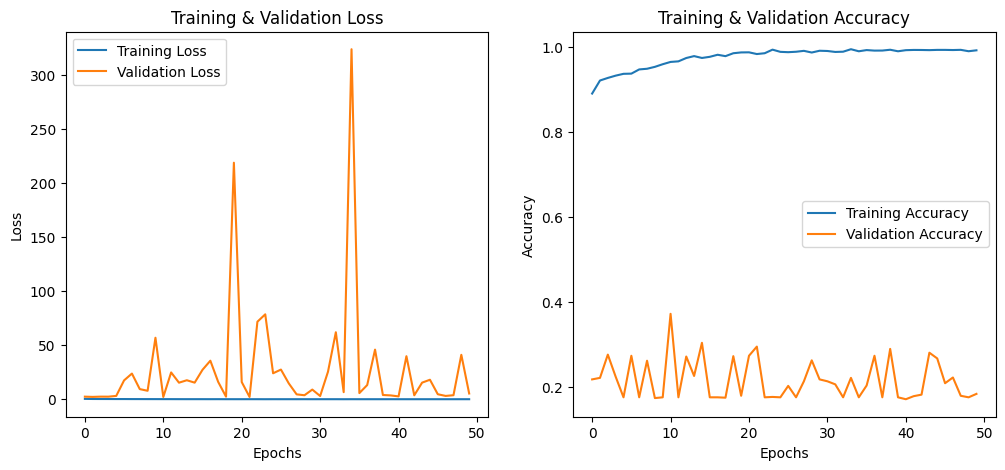

In [9]:
import matplotlib.pyplot as plt

def plot_loss_accuracy(history):
    # Plot Training & Validation Loss
    plt.figure(figsize=(12, 5))
    
    # Plot Loss
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Training & Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    # Plot Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Training & Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.show()

# After training the model, pass the history object to the function
plot_loss_accuracy(history)

for without auag to see change

In [11]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping

# Define image data generators for training and validation datasets
train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)

# Load train and validation datasets from directories
train_generator = train_datagen.flow_from_directory(
    r'C:\MyFolders\Projects\major_project\classification\dataset\aptos_resized_kaggle\split_data\train',  
    target_size=(224, 224),
    batch_size=8, 
    class_mode='categorical' 
)

validation_generator = val_datagen.flow_from_directory(
    r"C:\MyFolders\Projects\major_project\classification\dataset\aptos_resized_kaggle\split_data\val",
    target_size=(224, 224),
    batch_size=8,
    class_mode='categorical'
)

# Train the model for 50 epochs
history2 = model.fit(
    train_generator,
    epochs=10, 
    validation_data=validation_generator
)

Found 2929 images belonging to 5 classes.
Found 368 images belonging to 5 classes.
Epoch 1/10
367/367 [==============================] - 14s 37ms/step - loss: 0.2518 - accuracy: 0.9116 - val_loss: 58.5159 - val_accuracy: 0.2717
Epoch 2/10
367/367 [==============================] - 14s 37ms/step - loss: 0.1700 - accuracy: 0.9433 - val_loss: 73.4466 - val_accuracy: 0.1033
Epoch 3/10
367/367 [==============================] - 13s 36ms/step - loss: 0.1323 - accuracy: 0.9597 - val_loss: 10.6726 - val_accuracy: 0.1005
Epoch 4/10
367/367 [==============================] - 13s 35ms/step - loss: 0.1105 - accuracy: 0.9638 - val_loss: 39.1365 - val_accuracy: 0.3397
Epoch 5/10
367/367 [==============================] - 13s 36ms/step - loss: 0.1021 - accuracy: 0.9689 - val_loss: 3.8559 - val_accuracy: 0.1033
Epoch 6/10
367/367 [==============================] - 14s 38ms/step - loss: 0.0932 - accuracy: 0.9689 - val_loss: 6.2147 - val_accuracy: 0.1005
Epoch 7/10
367/367 [=============================

In [12]:
test_datagen = ImageDataGenerator(rescale=1./255)

# Load train and validation datasets from directories
test_generator = train_datagen.flow_from_directory(
    r'C:\MyFolders\Projects\major_project\classification\dataset\aptos_resized_kaggle\split_data\test',  
    target_size=(224, 224),
    batch_size=8, 
    class_mode='categorical' 
)

# Evaluate on test set
test_loss, test_acc = model.evaluate(test_generator)
print(f'Test Accuracy: {test_acc}')

Found 365 images belonging to 5 classes.
46/46 [==============================] - 1s 26ms/step - loss: 37.4392 - accuracy: 0.1014
Test Accuracy: 0.10136986523866653


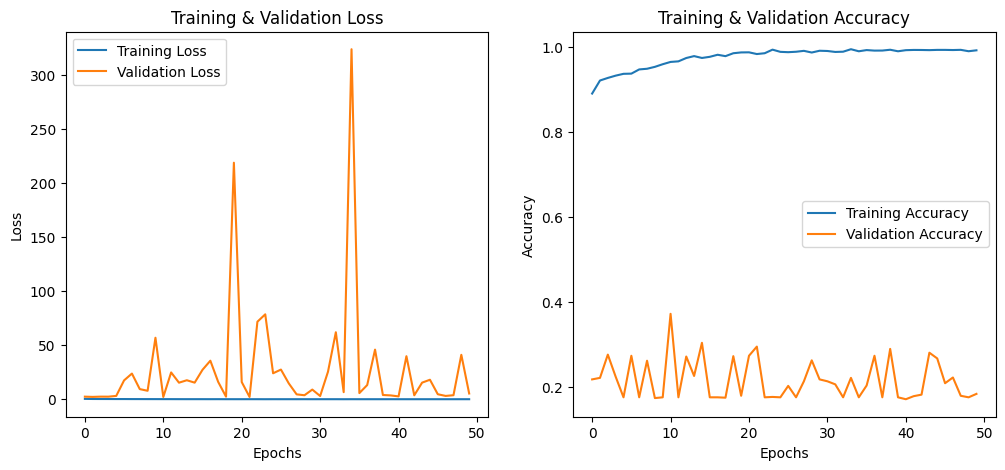

In [13]:
import matplotlib.pyplot as plt

def plot_loss_accuracy(history):
    # Plot Training & Validation Loss
    plt.figure(figsize=(12, 5))
    
    # Plot Loss
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Training & Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    # Plot Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Training & Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.show()

# After training the model, pass the history object to the function
plot_loss_accuracy(history)

In [17]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV3Small

# Define Squeeze-and-Excitation block
def squeeze_excite_block(input_tensor, ratio=16):
    filters = input_tensor.shape[-1]
    se = layers.GlobalAveragePooling2D()(input_tensor)  # Global pooling only applied once
    se = layers.Reshape((1, 1, filters))(se)
    se = layers.Dense(filters // ratio, activation='relu', use_bias=False)(se)
    se = layers.Dense(filters, activation='sigmoid', use_bias=False)(se)
    x = layers.Multiply()([input_tensor, se])
    return x

# Define the MobileNetV3-Small model with Squeeze-and-Excitation (SE) blocks for a 5-class classification task
def create_mobilenetv3_small(input_shape=(224, 224, 3), classes=5):
    # Load the pre-trained MobileNetV3-Small model, excluding the top classification layer
    base_model = MobileNetV3Small(input_shape=input_shape, include_top=False, weights='imagenet')

    # Add SE block before global average pooling
    x = squeeze_excite_block(base_model.output)  # SE block before pooling

    # Global Average Pooling
    x = layers.GlobalAveragePooling2D()(x)

  

    # Final dense layer with softmax activation for 5 classes
    outputs = layers.Dense(classes, activation='softmax')(x)

    # Create the final model
    model = models.Model(inputs=base_model.input, outputs=outputs)

    return model

# Create the MobileNetV3-Small model
model = create_mobilenetv3_small()

# Compile the model using categorical crossentropy for multiclass classification
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Model summary
model.summary()

Model: "model_2"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_7 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 rescaling_6 (Rescaling)        (None, 224, 224, 3)  0           ['input_7[0][0]']                
                                                                                                  
 Conv (Conv2D)                  (None, 112, 112, 16  432         ['rescaling_6[0][0]']            
                                )                                                                 
                                                                                            

In [18]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping

# Define image data generators for training and validation datasets
train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)

# Load train and validation datasets from directories
train_generator = train_datagen.flow_from_directory(
    r'C:\MyFolders\Projects\major_project\classification\dataset\aptos_resized_kaggle\aug_split_data\train',  
    target_size=(224, 224),
    batch_size=8, 
    class_mode='categorical' 
)

validation_generator = val_datagen.flow_from_directory(
    r"C:\MyFolders\Projects\major_project\classification\dataset\aptos_resized_kaggle\aug_split_data\val",
    target_size=(224, 224),
    batch_size=8,
    class_mode='categorical'
)

# Train the model for 50 epochs
history = model.fit(
    train_generator,
    epochs=10, 
    validation_data=validation_generator
)

Found 8883 images belonging to 5 classes.
Found 1113 images belonging to 5 classes.
Epoch 1/10
1111/1111 [==============================] - 44s 36ms/step - loss: 0.3265 - accuracy: 0.8916 - val_loss: 1.9422 - val_accuracy: 0.1752
Epoch 2/10
1111/1111 [==============================] - 40s 36ms/step - loss: 0.2270 - accuracy: 0.9198 - val_loss: 2.4603 - val_accuracy: 0.1761
Epoch 3/10
1111/1111 [==============================] - 40s 36ms/step - loss: 0.2039 - accuracy: 0.9283 - val_loss: 2.9319 - val_accuracy: 0.1806
Epoch 4/10
1111/1111 [==============================] - 38s 34ms/step - loss: 0.1860 - accuracy: 0.9327 - val_loss: 2.4461 - val_accuracy: 0.3522
Epoch 5/10
1111/1111 [==============================] - 90s 81ms/step - loss: 0.1663 - accuracy: 0.9367 - val_loss: 3.5391 - val_accuracy: 0.3414
Epoch 6/10
1111/1111 [==============================] - 39s 35ms/step - loss: 0.1571 - accuracy: 0.9437 - val_loss: 8.1057 - val_accuracy: 0.2731
Epoch 7/10
1111/1111 [==================

Found 1110 images belonging to 5 classes.
139/139 [==============================] - 2s 15ms/step - loss: 13.8446 - accuracy: 0.2081
Test Accuracy: 0.2081081122159958


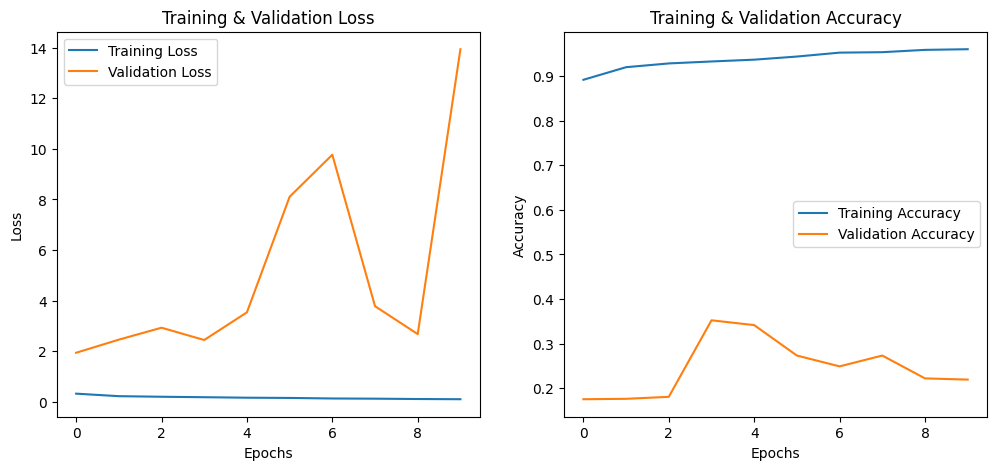

In [20]:
test_datagen = ImageDataGenerator(rescale=1./255)

# Load train and validation datasets from directories
test_generator = train_datagen.flow_from_directory(
    r'C:\MyFolders\Projects\major_project\classification\dataset\aptos_resized_kaggle\aug_split_data\test',  
    target_size=(224, 224),
    batch_size=8, 
    class_mode='categorical' 
)

# Evaluate on test set
test_loss, test_acc = model.evaluate(test_generator)
print(f'Test Accuracy: {test_acc}')

import matplotlib.pyplot as plt

def plot_loss_accuracy(history):
    # Plot Training & Validation Loss
    plt.figure(figsize=(12, 5))
    
    # Plot Loss
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Training & Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    # Plot Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Training & Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.show()

# After training the model, pass the history object to the function
plot_loss_accuracy(history)